# Visualizations of Numerical Examples

## Small-Scale Hypergraphs

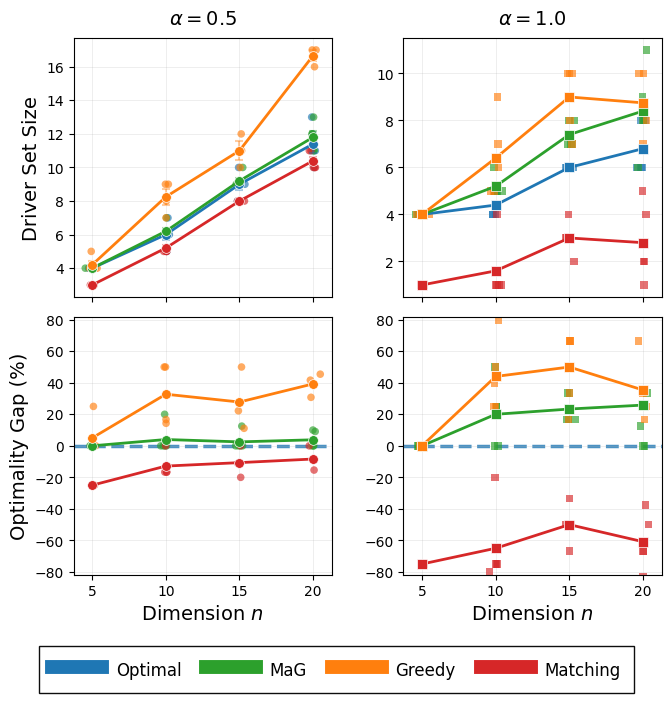

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math
from matplotlib.lines import Line2D

# IEEE style configuration
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'lines.linewidth': 2.0,
    'lines.markersize': 6,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
})

# Load the data
df = pd.read_csv('EXP1_per_trial.csv')

# Consistent color scheme across all plots
method_colors = {
    'matching': '#d62728',      # Red
    'pure_greedy': '#ff7f0e',   # Orange
    'greedy': '#2ca02c',        # Green
    'optimal': '#1f77b4'        # Blue
}

method_labels = {
    'matching': 'Matching (Linear)',
    'pure_greedy': 'Greedy (Heuristic)',
    'greedy': 'Match and Greedy (Ours)',
    'optimal': 'Optimal (Brute Force)'
}

# Alpha markers for consistency
alpha_markers = {
    0.5: 'o',   # circle
    1.0: 's',   # square
    1.5: '^',   # triangle
}

# Create 2x2 figure
plt_size = 3.5
fig, axs = plt.subplots(2, 2, figsize=(plt_size * 2, plt_size * 2), sharex=True)

k = 4  # Focus on k=4
fontsize = 14

# ============================================================================
# SUBPLOT [0,0]: Absolute Performance (Driver Set Size)
# ============================================================================
ax = axs[0, 0]
df_k = df[df['k'] == k].copy()
df_k = df_k[df_k['alpha'] == 0.5]

for method_col, method_key in [
    ('optimal_size', 'optimal'),
    ('greedy_size', 'greedy'),
    ('pure_greedy_size', 'pure_greedy'),
    ('matching_size', 'matching'),
]:
    color = method_colors[method_key]
    label = method_labels[method_key]

    for alpha in sorted(df_k['alpha'].unique()):
        df_alpha = df_k[df_k['alpha'] == alpha]
        for n in sorted(df_alpha['n'].unique()):
            df_n = df_alpha[df_alpha['n'] == n]
            sizes = df_n[method_col].values
            x_jitter = n * np.ones_like(sizes) + np.random.normal(0, 0.15, len(sizes))
            ax.scatter(x_jitter, sizes, color=color, alpha=0.65,
                       s=30, zorder=1, edgecolors='none',
                       marker=alpha_markers[alpha])

    for alpha in sorted(df_k['alpha'].unique()):
        df_alpha = df_k[df_k['alpha'] == alpha]
        grouped = df_alpha.groupby('n')[method_col].agg(['mean', 'std', 'count'])

        n_vals = grouped.index.values
        means = grouped['mean'].values
        stds = grouped['std'].values
        ses = stds / np.sqrt(grouped['count'].values)

        linestyle = {0.5: '-', 1.0: '-', 1.5: ':'}[alpha]
        plot_label = label if alpha == 0.5 else None

        ax.plot(n_vals, means, color=color, linestyle=linestyle,
                linewidth=2.0, label=plot_label, zorder=3,
                marker=alpha_markers[alpha], markersize=7,
                markeredgewidth=0.5, markeredgecolor='white')

        ax.errorbar(n_vals, means, yerr=ses, color=color, alpha=0.4,
                    linewidth=1.5, capsize=3, capthick=1.5,
                    linestyle='none', zorder=2)

# ax.set_xlabel('Dimension $n$', fontsize=fontsize, fontweight='bold')
ax.set_ylabel('Driver Set Size', fontsize=fontsize)
ax.set_title(r'$\alpha=0.5$',fontsize=fontsize, pad=10)
#ax.set_title('(a) Absolute Performance', fontsize=fontsize, fontweight='bold', pad=10)
ax.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)
ax.set_box_aspect(1)

# ============================================================================
# SUBPLOT [0,1]: Optimality Gap
# ============================================================================
ax = axs[1, 0]
df_gap = df[df['k'] == k].copy()
df_gap = df_gap[df_gap['alpha'] == 0.5]
df_gap['gap_matching'] = (df_gap['matching_size'] - df_gap['optimal_size']) / df_gap['optimal_size'] * 100
df_gap['gap_pure_greedy'] = (df_gap['pure_greedy_size'] - df_gap['optimal_size']) / df_gap['optimal_size'] * 100
df_gap['gap_greedy'] = (df_gap['greedy_size'] - df_gap['optimal_size']) / df_gap['optimal_size'] * 100

for gap_col, method_key in [
    ('gap_greedy', 'greedy'),
    ('gap_pure_greedy', 'pure_greedy'),
    ('gap_matching', 'matching'),
]:
    color = method_colors[method_key]
    label = method_labels[method_key]

    for alpha in sorted(df_gap['alpha'].unique()):
        df_alpha = df_gap[df_gap['alpha'] == alpha]
        for n in sorted(df_alpha['n'].unique()):
            df_n = df_alpha[df_alpha['n'] == n]
            gaps = df_n[gap_col].values
            x_jitter = n * np.ones_like(gaps) + np.random.normal(0, 0.15, len(gaps))
            ax.scatter(x_jitter, gaps, color=color, alpha=0.65,
                       s=30, zorder=1, edgecolors='none',
                       marker=alpha_markers[alpha])

    for alpha in sorted(df_gap['alpha'].unique()):
        df_alpha = df_gap[df_gap['alpha'] == alpha]
        grouped = df_alpha.groupby('n')[gap_col].agg(['mean', 'std', 'count'])

        n_vals = grouped.index.values
        means = grouped['mean'].values
        stds = grouped['std'].values
        ses = stds / np.sqrt(grouped['count'].values)

        linestyle = {0.5: '-', 1.0: '-', 1.5: ':'}[alpha]
        plot_label = label if alpha == 0.5 else None

        ax.plot(n_vals, means, color=color, linestyle=linestyle,
                linewidth=2.0, label=plot_label, zorder=3,
                marker=alpha_markers[alpha], markersize=7,
                markeredgewidth=0.5, markeredgecolor='white')

#        ax.errorbar(n_vals, means, yerr=ses, color=color, alpha=0.4,
#                    linewidth=1.5, capsize=3, capthick=1.5,
#                    linestyle='none', zorder=2)

ax.axhline(y=0, color=method_colors['optimal'], linestyle='--', linewidth=2.5,
           alpha=0.8, zorder=0, label='Optimal (0% gap)')

ax.set_xlabel('Dimension $n$', fontsize=fontsize) #, fontweight='bold')
ax.set_ylabel('Optimality Gap (%)', fontsize=fontsize) #, fontweight='bold')
#ax.set_title('(b) Optimality Gap', fontsize=fontsize, fontweight='bold', pad=10)
ax.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)
ax.set_box_aspect(1)

# ============================================================================
# SUBPLOT [0,0]: Absolute Performance (Driver Set Size)
# ============================================================================
ax = axs[0, 1]
df_k = df[df['k'] == k].copy()
df_k = df_k[df_k['alpha'] == 1.0]

for method_col, method_key in [
    ('optimal_size', 'optimal'),
    ('greedy_size', 'greedy'),
    ('pure_greedy_size', 'pure_greedy'),
    ('matching_size', 'matching'),
]:
    color = method_colors[method_key]
    label = method_labels[method_key]

    for alpha in sorted(df_k['alpha'].unique()):
        df_alpha = df_k[df_k['alpha'] == alpha]
        for n in sorted(df_alpha['n'].unique()):
            df_n = df_alpha[df_alpha['n'] == n]
            sizes = df_n[method_col].values
            x_jitter = n * np.ones_like(sizes) + np.random.normal(0, 0.15, len(sizes))
            ax.scatter(x_jitter, sizes, color=color, alpha=0.65,
                       s=30, zorder=1, edgecolors='none',
                       marker=alpha_markers[alpha])

    for alpha in sorted(df_k['alpha'].unique()):
        df_alpha = df_k[df_k['alpha'] == alpha]
        grouped = df_alpha.groupby('n')[method_col].agg(['mean', 'std', 'count'])

        n_vals = grouped.index.values
        means = grouped['mean'].values
        stds = grouped['std'].values
        ses = stds / np.sqrt(grouped['count'].values)

        linestyle = {0.5: '-', 1.0: '-', 1.5: ':'}[alpha]
        plot_label = label if alpha == 0.5 else None

        ax.plot(n_vals, means, color=color, linestyle=linestyle,
                linewidth=2.0, label=plot_label, zorder=3,
                marker=alpha_markers[alpha], markersize=7,
                markeredgewidth=0.5, markeredgecolor='white')

#        ax.errorbar(n_vals, means, yerr=ses, color=color, alpha=0.4,
#                    linewidth=1.5, capsize=3, capthick=1.5,
#                    linestyle='none', zorder=2)

#ax.set_xlabel('Dimension $n$', fontsize=fontsize, fontweight='bold')
#ax.set_ylabel('Driver Set Size', fontsize=fontsize, fontweight='bold')
#ax.set_title('(a) Absolute Performance', fontsize=fontsize, fontweight='bold', pad=10)
ax.set_title(r'$\alpha=1.0$',fontsize=fontsize, fontweight='bold', pad=10)
ax.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)
ax.set_box_aspect(1)

# ============================================================================
# SUBPLOT [1,1]: Optimality Gap
# ============================================================================
ax = axs[1, 1]
df_gap = df[df['k'] == k].copy()
df_gap = df_gap[df_gap['alpha'] == 1.0]
df_gap['gap_matching'] = (df_gap['matching_size'] - df_gap['optimal_size']) / df_gap['optimal_size'] * 100
df_gap['gap_pure_greedy'] = (df_gap['pure_greedy_size'] - df_gap['optimal_size']) / df_gap['optimal_size'] * 100
df_gap['gap_greedy'] = (df_gap['greedy_size'] - df_gap['optimal_size']) / df_gap['optimal_size'] * 100

for gap_col, method_key in [
    ('gap_greedy', 'greedy'),
    ('gap_pure_greedy', 'pure_greedy'),
    ('gap_matching', 'matching'),
]:
    color = method_colors[method_key]
    label = method_labels[method_key]

    for alpha in sorted(df_gap['alpha'].unique()):
        df_alpha = df_gap[df_gap['alpha'] == alpha]
        for n in sorted(df_alpha['n'].unique()):
            df_n = df_alpha[df_alpha['n'] == n]
            gaps = df_n[gap_col].values
            x_jitter = n * np.ones_like(gaps) + np.random.normal(0, 0.15, len(gaps))
            ax.scatter(x_jitter, gaps, color=color, alpha=0.65,
                       s=30, zorder=1, edgecolors='none',
                       marker=alpha_markers[alpha])

    for alpha in sorted(df_gap['alpha'].unique()):
        df_alpha = df_gap[df_gap['alpha'] == alpha]
        grouped = df_alpha.groupby('n')[gap_col].agg(['mean', 'std', 'count'])

        n_vals = grouped.index.values
        means = grouped['mean'].values
        stds = grouped['std'].values
        ses = stds / np.sqrt(grouped['count'].values)

        linestyle = {0.5: '-', 1.0: '-', 1.5: ':'}[alpha]
        plot_label = label if alpha == 0.5 else None

        ax.plot(n_vals, means, color=color, linestyle=linestyle,
                linewidth=2.0, label=plot_label, zorder=3,
                marker=alpha_markers[alpha], markersize=7,
                markeredgewidth=0.5, markeredgecolor='white')

#        ax.errorbar(n_vals, means, yerr=ses, color=color, alpha=0.4,
#                    linewidth=1.5, capsize=3, capthick=1.5,
#                    linestyle='none', zorder=2)

ax.axhline(y=0, color=method_colors['optimal'], linestyle='--', linewidth=2.5,
           alpha=0.8, zorder=0, label='Optimal (0% gap)')

ax.set_xlabel('Dimension $n$', fontsize=fontsize)
#ax.set_ylabel('Optimality Gap (\%)', fontsize=fontsize, fontweight='bold')
#ax.set_title('(b) Optimality Gap', fontsize=fontsize, fontweight='bold', pad=10)
ax.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)
ax.set_box_aspect(1)

# Method handles
method_handles = [
    Line2D([0], [0], color=method_colors['optimal'], linewidth=2.5, label='Optimal (Brute Force)'),
    Line2D([0], [0], color=method_colors['greedy'], linewidth=2.5, label='Match and Greedy (Ours)'),
    Line2D([0], [0], color=method_colors['pure_greedy'], linewidth=2.5, label='Greedy (Heuristic)'),
    Line2D([0], [0], color=method_colors['matching'], linewidth=2.5, label='Matching (Linear)'),
]

# Alpha line-style handles
alpha_handles = [
    Line2D([0], [0], color='gray', linewidth=2.5, linestyle='-',  marker='o', markersize=7, label=r'$\alpha=0.5$'),
    Line2D([0], [0], color='gray', linewidth=2.5, linestyle='--', marker='s', markersize=7, label=r'$\alpha=1.0$'),
    Line2D([0], [0], color='gray', linewidth=2.5, linestyle=':',  marker='^', markersize=7, label=r'$\alpha=1.5$'),
]

# Spacer (invisible blank entry)
spacer = Line2D([0], [0], color='none', label='')

all_handles = method_handles + [spacer] + alpha_handles

#ax_leg.legend(handles=all_handles, loc='center left',
#              ncol=1, frameon=True, fancybox=False, shadow=False,
#              framealpha=0.95, edgecolor='white', facecolor='white',
#              fontsize=fontsize - 4, handlelength=2.8, handleheight=1.8,
#              borderpad=0.8, labelspacing=0.6)

axs[1,0].set_ylim([-82, 82])
axs[1,1].set_ylim([-82, 82])
axs[1,0].set_xticks([5, 10, 15, 20])
axs[1,1].set_xticks([5, 10, 15, 20])

from matplotlib.lines import Line2D

method_handles = [
    Line2D([0], [0], color=method_colors['optimal'],    linewidth=10, label='Optimal'),
    Line2D([0], [0], color=method_colors['greedy'],     linewidth=10, label='MaG'),
    Line2D([0], [0], color=method_colors['pure_greedy'],linewidth=10, label='Greedy'),
    Line2D([0], [0], color=method_colors['matching'],   linewidth=10, label='Matching'),
]

fig.legend(
    handles=method_handles,
    loc='lower center',
    ncol=4,
    frameon=True,
    fancybox=False,
    framealpha=0.95,
    edgecolor='k',
    fontsize=fontsize - 2,
    handlelength=3.0,
    handleheight=1.5,
    borderpad=0.8,
    columnspacing=1.5,
    bbox_to_anchor=(0.5, -0.01),  # adjust vertical offset as needed
)

plt.tight_layout(rect=[0, 0.08, 1, 1])  # leave room at bottom for legend

# ============================================================================
# Final layout and save
# ============================================================================
#plt.tight_layout(pad=1.2)
plt.savefig('fig_exp_1_v4.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [2]:
df20 = df[df['n'] == 20]
df20

,trial_id,n,k,m,alpha,matching_size,greedy_size,pure_greedy_size,optimal_size,time_matching,time_mg,time_pg,time_optimal
70,71,20,4,10,0.5,10,12,16.0,11,0.000617,0.000745,0.001263,507.753785
71,72,20,4,10,0.5,11,12,17.0,12,0.000507,0.000616,0.001175,451.095593
72,73,20,4,10,0.5,11,13,17.0,13,0.000379,0.000577,0.000750,477.062527
73,74,20,4,10,0.5,10,11,NaN,10,0.000572,0.000658,NaN,330.487049
74,75,20,4,10,0.5,10,11,NaN,11,0.000381,0.000462,NaN,332.649660
75,76,20,4,20,1.0,1,8,8.0,6,0.000669,0.000959,0.001124,41.868126
76,77,20,4,20,1.0,2,11,10.0,6,0.000730,0.001065,0.001015,47.563550
77,78,20,4,20,1.0,5,9,10.0,8,0.001193,0.001410,0.001297,239.145714
78,79,20,4,20,1.0,4,8,NaN,8,0.000651,0.000876,NaN,178.116079
79,80,20,4,20,1.0,2,6,7.0,6,0.000994,0.001208,0.001052,43.850442


## Scalability Analysis on Large-Scale Hypergraphs

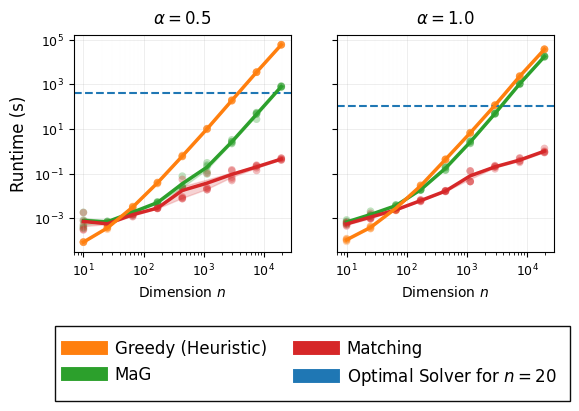

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

df = pd.read_csv("EXP2_v3.csv")

# IEEE style configuration
plt.rcParams.update({
    'font.serif': ['Times New Roman'],
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'figure.titlesize': 11,
    'lines.linewidth': 1.5,
    'lines.markersize': 4,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
})

fontsize = 12

# Colors consistent with the rest of the paper
method_colors = {
    'matching': '#d62728',       # Red
    'pure_greedy': '#ff7f0e',    # Orange
    'greedy': '#2ca02c',         # Green  (MaG)
    'optimal': '#1f77b4'        # Blue
}

method_labels = {
    'matching': 'Matching',
    'pure_greedy': 'Greedy (Heuristic)',
    'greedy': 'MaG',
}

# Filter to alpha = 1 and alpha = 2 only
alphas_to_plot = [0.5, 1.0]
df = df[df['alpha'].isin(alphas_to_plot)].copy()

# Derive driver-node counts
df['n_matching'] = df['n'] * df['ratio_matching']
df['n_greedy'] = df['n'] * df['ratio_greedy']
df['n_pure_greedy'] = df['n'] * df['ratio_pure_greedy']

# --------------------------------------------------------------------
# Layout: 2 rows x 2 cols
#   Row 0: runtime      (left = alpha 1, right = alpha 2)
#   Row 1: driver nodes (left = alpha 1, right = alpha 2)
# --------------------------------------------------------------------
subplot_size = 3.0
fig, axs = plt.subplots(1, 2, figsize=(2 * subplot_size, subplot_size),
                         squeeze=False, sharey='row', sharex=True)

# Runtime column definitions
runtime_cols = {
    'matching': 'time_matching',
    'greedy': 'time_mg',
    'pure_greedy': 'time_pg',
}

# Driver-node column definitions
driver_cols = {
    'matching': 'n_matching',
    'greedy': 'n_greedy',
    'pure_greedy': 'n_pure_greedy',
}

for col_idx, alpha in enumerate(alphas_to_plot):
    pdf = df[df['alpha'] == alpha].copy()

    # ----------------------------------------------------------
    # ROW 0: Runtime
    # ----------------------------------------------------------
    ax = axs[0, col_idx]
    for method_key in ['greedy', 'matching', 'pure_greedy']:
        col = runtime_cols[method_key]
        color = method_colors[method_key]
        label = method_labels[method_key]

        grouped = pdf.groupby('n')[col].agg(['mean', 'sem'])

        ax.plot(grouped.index, grouped['mean'],
                color=color, label=label, linewidth=2.5, zorder=3)
        ax.fill_between(grouped.index,
                        grouped['mean'] - grouped['sem'],
                        grouped['mean'] + grouped['sem'],
                        color=color, alpha=0.2, zorder=2)
        ax.scatter(pdf['n'], pdf[col],
                   color=color, alpha=0.3, s=30, zorder=1, edgecolors='none')

    ax.axhline(y=df20[df20['alpha'] == alpha]['time_optimal'].mean(), color=method_colors['optimal'], linestyle='--')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.5)
    ax.grid(True, which='minor', alpha=0.15, linestyle=':', linewidth=0.3)
    ax.set_title(fr'$\alpha = {(alpha)}$', fontsize=fontsize, pad=8)
#    ax.set_xlabel('Dimension $n$', fontsize=fontsize)
    if col_idx == 0:
        ax.set_ylabel('Runtime (s)', fontsize=fontsize)

    ax.set_xlabel(r'Dimension $n$')

for ax in axs.flat:
    ax.set_box_aspect(1)

# ----------------------------------------------------------
# Single shared legend, placed to the right
# ----------------------------------------------------------
handles = [
    Line2D([0], [0], color=method_colors['pure_greedy'], linewidth=10, label=method_labels['pure_greedy']),
    Line2D([0], [0], color=method_colors['greedy'],      linewidth=10, label=method_labels['greedy']),
    Line2D([0], [0], color=method_colors['matching'],    linewidth=10, label=method_labels['matching']),
    Line2D([0], [0], color=method_colors['optimal'],     linewidth=10, label=r'Optimal Solver for $n=20$')
]

fig.legend(handles=handles,
           loc='lower center',    # below the axes
           ncol=2,                # 2 columns
           frameon=True,
           fancybox=False,
           shadow=False,
           framealpha=0.95,
           edgecolor='k',
            borderpad=0.8,
           facecolor='white',
           fontsize=fontsize,
           bbox_to_anchor=(0.55, -0.35))  # centered, just below figure

plt.tight_layout()
plt.savefig('fig_exp_2_v3.pdf', bbox_inches='tight', dpi=150)
plt.show()

## Hypergraph Topologies

/tmp/ipykernel_1595989/1269503619.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


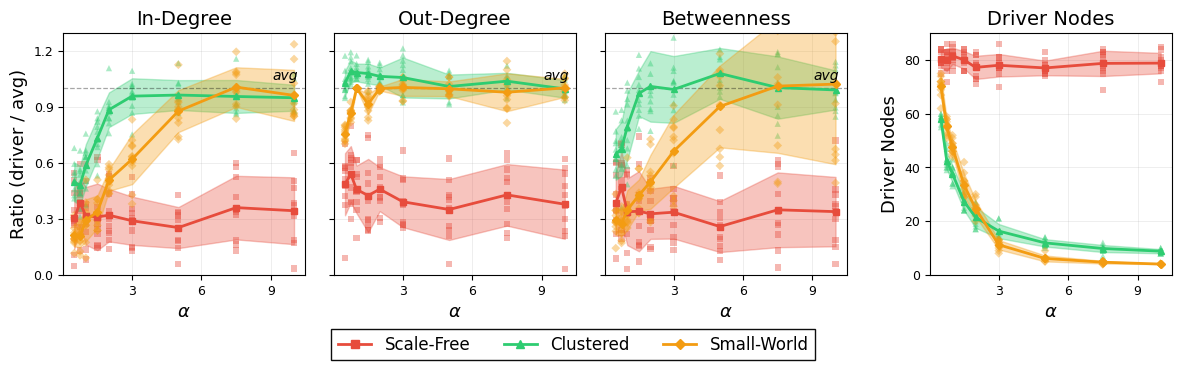

Saved EXP_3.{pdf,png}


In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

# ============================================================================
# GLOBAL STYLE
# ============================================================================
FONT_SMALL  = 12
FONT_MED    = 13
FONT_LARGE  = 14
DPI_SAVE    = 200

TOPO_ORDER  = ['scale_free', 'clustered', 'small_world']
TOPO_LABELS = {
    'scale_free':  'Scale-Free',
    'clustered':   'Clustered',
    'small_world': 'Small-World',
}
TOPO_COLORS = {
    'scale_free':  '#e74c3c',
    'clustered':   '#2ecc71',
    'small_world': '#f39c12',
}
TOPO_MARKERS = {
    'scale_free':  's',
    'clustered':   '^',
    'small_world': 'D',
}

TOPOLOGY_ORDER = TOPO_ORDER


def _topo_panel(ax, df, col, title, ylabel, show_ylabel=False, ref_line=False, TOPO_ORDER=None):
    for topo in TOPO_ORDER:
        sub = df[df['topology'] == topo]
        grp = (sub.groupby('alpha')[col]
               .agg(['mean', 'std'])
               .reset_index()
               .sort_values('alpha'))

        ax.scatter(sub['alpha'], sub[col],
                   color=TOPO_COLORS[topo], marker=TOPO_MARKERS[topo],
                   alpha=0.4, s=20, zorder=1, edgecolors='none')
        ax.plot(grp['alpha'], grp['mean'],
                color=TOPO_COLORS[topo], marker=TOPO_MARKERS[topo],
                label=TOPO_LABELS[topo], linewidth=2.0, zorder=3)
        ax.fill_between(grp['alpha'],
                        grp['mean'] - 1.0 * grp['std'],
                        grp['mean'] + 1.0 * grp['std'],
                        color=TOPO_COLORS[topo], alpha=0.33)

    if ref_line:
        ax.axhline(1.0, color='black', linestyle='--', linewidth=0.9, alpha=0.35)
        ax.text(ax.get_xlim()[1] * 0.97, 1.03, 'avg',
                fontsize=FONT_SMALL - 2, color='black', alpha=1,
                style='italic', ha='right', va='bottom')

    ax.set_title(title, fontsize=FONT_LARGE, pad=6)
    ax.set_xlabel(r'$\alpha$', fontsize=FONT_MED)

    if show_ylabel:
        ax.set_ylabel(ylabel, fontsize=FONT_MED)

    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)

    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))


def figure3(csv_path='EXP_topology.csv'):
    df = pd.read_csv(csv_path)

    panels = [
        {'col': 'mg_ratio_in_degree',   'title': 'In-Degree',    'ylabel': 'Ratio (driver / avg)', 'ref': True,  'share_y': True},
        {'col': 'mg_ratio_out_degree',  'title': 'Out-Degree',   'ylabel': 'Ratio (driver / avg)', 'ref': True,  'share_y': True},
        {'col': 'mg_ratio_betweenness', 'title': 'Betweenness',  'ylabel': 'Ratio (driver / avg)', 'ref': True,  'share_y': True},
        {'col': 'greedy_size',          'title': 'Driver Nodes', 'ylabel': 'Driver Nodes',         'ref': False, 'share_y': False},
    ]

    fig = plt.figure(figsize=(13.6, 3.2))

    # Flat GridSpec — all 4 panels identical width
    gs = GridSpec(1, 4, figure=fig, wspace=0.12)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
    ax3 = fig.add_subplot(gs[0, 2], sharey=ax1)
    ax4 = fig.add_subplot(gs[0, 3])

    axes = [ax1, ax2, ax3, ax4]

    for i, (ax, p) in enumerate(zip(axes, panels)):
        show_ylabel = (i == 0) or (not p['share_y'])
        _topo_panel(ax, df, p['col'], p['title'], p['ylabel'],
                    show_ylabel=show_ylabel, ref_line=p['ref'], TOPO_ORDER=TOPOLOGY_ORDER)

        if p['share_y'] and i > 0:
            ax.tick_params(labelleft=False)

        ax.set_box_aspect(1)
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)

    # Fresh legend handles to avoid mutating plotted lines
    legend_handles = [
        Line2D([0], [0], color=TOPO_COLORS[t], marker=TOPO_MARKERS[t],
               linewidth=2.0, markersize=5.5, label=TOPO_LABELS[t])
        for t in TOPOLOGY_ORDER
    ]
    fig.legend(legend_handles, [TOPO_LABELS[t] for t in TOPOLOGY_ORDER],
               loc='lower center', ncol=3,
               frameon=True, fancybox=False, framealpha=0.95,
               edgecolor='k', fontsize=FONT_SMALL,
               bbox_to_anchor=(0.5, -0.175))

    # tight_layout first, then nudge ax4 right for y-axis label breathing room
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    pos4 = ax4.get_position()
    ax4.set_position([pos4.x0 + 0.04, pos4.y0, pos4.width, pos4.height])

    fig.savefig('EXP_3.pdf', dpi=DPI_SAVE, bbox_inches='tight')
    fig.savefig('EXP_3.png', dpi=DPI_SAVE, bbox_inches='tight')
    plt.show()
    print('Saved EXP_3.{pdf,png}')

figure3('EXP_topology.csv')

# END